In [9]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import learning_curve

import numpy as np
import joblib
import random
from scipy.ndimage import rotate, shift, zoom
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline  # 파이프라인 추가
# Single Model imports
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Ensemble imports
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression



In [10]:
# ==========================================
# 1. 사용자 정의 전처리 클래스 (그대로 유지)
# ==========================================
class CustomImagePreprocess(BaseEstimator, TransformerMixin):
    def __init__(self, stroke_target=0.4, target_size=20, final_size=28, noise_threshold=0.02):
        self.stroke_target = stroke_target       
        self.target_size = target_size           
        self.final_size = final_size             
        self.noise_threshold = noise_threshold   
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        X = np.array(X)
        if X.ndim == 2:
            side = int(np.sqrt(X.shape[1]))
            X = X.reshape(-1, side, side)
        
        processed = []
        for img in X:
            img = self.normalize_scale(img)   
            img = self.remove_noise(img)      
            img = self.normalize_stroke(img)  
            img = self.normalize_size(img)    
            img = self.center_align(img)
            processed.append(img)
        
        processed = np.array(processed)
        return processed.reshape(len(processed), -1)
    
    # --- 내부 메서드 ---
    def normalize_scale(self, img):
        img = img.astype(np.float32)
        if img.max() > 1: img = img / 255.0
        return img
    
    def remove_noise(self, img):
        img = img.copy()
        img[img < self.noise_threshold] = 0.0
        return img
    
    def normalize_stroke(self, img):
        mask = img > 0.05
        if mask.sum() == 0: return img
        mean_val = img[mask].mean()
        if mean_val == 0: return img
        scale_factor = self.stroke_target / mean_val
        img = img * scale_factor
        img = np.clip(img, 0, 1)
        return img
    
    def normalize_size(self, img):
        coords = np.where(img > 0.05)
        if coords[0].size == 0: return np.zeros((self.final_size, self.final_size))
        r1, r2 = coords[0].min(), coords[0].max()
        c1, c2 = coords[1].min(), coords[1].max()
        digit = img[r1:r2+1, c1:c2+1]
        h, w = digit.shape
        if h == 0 or w == 0: return np.zeros((self.final_size, self.final_size))
        zoom_h = self.target_size / h
        zoom_w = self.target_size / w
        digit_resized = zoom(digit, (zoom_h, zoom_w))
        return digit_resized
    
    def center_align(self, img):
        canvas = np.zeros((self.final_size, self.final_size))
        h, w = img.shape
        if h > self.final_size or w > self.final_size:
            h_start = (h - self.final_size) // 2
            w_start = (w - self.final_size) // 2
            img = img[h_start:h_start+self.final_size, w_start:w_start+self.final_size]
            h, w = img.shape
        y0 = (self.final_size - h) // 2
        x0 = (self.final_size - w) // 2
        canvas[y0:y0+h, x0:x0+w] = img
        return canvas

In [11]:
# ==========================================
# 2. 데이터 증강 함수 (그대로 유지)
# ==========================================
def apply_augment_single(img, mode, rotate_range=15, shift_range=2, zoom_range=0.1):
    if mode == 'rotate':
        angle = random.uniform(-rotate_range, rotate_range)
        img = rotate(img, angle, reshape=False, mode='constant', cval=0)
    elif mode == 'shift':
        dx = random.uniform(-shift_range, shift_range)
        dy = random.uniform(-shift_range, shift_range)
        img = shift(img, [dy, dx], mode='constant', cval=0)
    elif mode == 'zoom':
        factor = random.uniform(1.0, 1.0 + zoom_range)
        h, w = img.shape
        zoomed_img = zoom(img, factor, mode='constant', cval=0)
        zh, zw = zoomed_img.shape
        start_h = max((zh - h) // 2, 0)
        start_w = max((zw - w) // 2, 0)
        img = zoomed_img[start_h:start_h+h, start_w:start_w+w]
        if img.shape != (28, 28):
            img = img[:28, :28]
    return img

def custom_augment(X, y, multiplier=1):
    if multiplier <= 1:
        return X, y

    X = np.array(X)
    y = np.array(y)
    
    if X.ndim == 2:
        X_reshaped = X.reshape(-1, 28, 28)
    else:
        X_reshaped = X

    X_out = []
    y_out = []

    for img, label in zip(X_reshaped, y):
        X_out.append(img)
        y_out.append(label)
        for _ in range(multiplier - 1):
            mode = random.choice(['rotate', 'shift', 'zoom'])
            aug_img = apply_augment_single(img, mode)
            X_out.append(aug_img)
            y_out.append(label)

    X_out = np.array(X_out).reshape(len(X_out), -1)
    y_out = np.array(y_out)
    return X_out, y_out

In [12]:
# ==========================================
# 3. 데이터 로드 및 전처리 (순서 유지: 전처리 -> 증강)
# ==========================================
def load_preprocess_and_augment(hand_path, org_path, augment_factor=1):
    print(f"\n[Data Prep] Loading & Preprocessing... Augment Factor: {augment_factor}x")
    
    # 1) 데이터 로드
    try:
        d_hand = np.load(hand_path, allow_pickle=True)
        X_hand, y_hand = d_hand['x_train'], d_hand['y_train'].astype(int)
        
        d_org = np.load(org_path, allow_pickle=True)
        X_org, y_org = d_org['x_train'], d_org['y_train'].astype(int)
    except Exception as e:
        print(f"Error loading files: {e}")
        return None, None, None, None

    # 2) 전처리 (먼저 수행)
    preprocessor = CustomImagePreprocess()
    print("  - Preprocessing Handmade data...")
    X_hand_processed = preprocessor.transform(X_hand)
    print("  - Preprocessing Original MNIST data...")
    X_org_processed = preprocessor.transform(X_org)

    # 3) 분할
    X_hand_tr, X_hand_te, y_hand_tr, y_hand_te = train_test_split(
        X_hand_processed, y_hand, test_size=0.2, random_state=42, stratify=y_hand
    )
    X_org_tr, X_org_te, y_org_tr, y_org_te = train_test_split(
        X_org_processed, y_org, test_size=0.2, random_state=42, stratify=y_org
    )

    # 4) 증강 (전처리된 데이터를 바탕으로 증강)
    if augment_factor > 1:
        print(f"  - Augmenting Handmade Train ({len(X_hand_tr)} -> {augment_factor}x)...")
        X_hand_tr, y_hand_tr = custom_augment(X_hand_tr, y_hand_tr, multiplier=augment_factor)
    
    # 5) 병합
    X_train = np.concatenate([X_hand_tr, X_org_tr])
    y_train = np.concatenate([y_hand_tr, y_org_tr])
    
    X_test = np.concatenate([X_hand_te, X_org_te])
    y_test = np.concatenate([y_hand_te, y_org_te])

    print(f"  - Final Train Size: {X_train.shape}, Test Size: {X_test.shape}")
    return X_train, X_test, y_train, y_test

In [13]:
hand_file = 'mnist_final_balanced.npz'
org_file  = 'mnist_sklearn_40000.npz'

factor = 4
print(f"\n🚀 Data prep with augment factor = {factor}x")
X_train, X_val, y_train, y_val = load_preprocess_and_augment(
    hand_file,
    org_file,
    augment_factor=factor
)



🚀 Data prep with augment factor = 4x

[Data Prep] Loading & Preprocessing... Augment Factor: 4x
  - Preprocessing Handmade data...
  - Preprocessing Original MNIST data...
  - Augmenting Handmade Train (8896 -> 4x)...
  - Final Train Size: (67584, 784), Test Size: (10224, 784)


In [14]:

models = []


mlp_base = MLPClassifier(
    solver="adam",
    max_iter=200,
    learning_rate_init=0.001,
    hidden_layer_sizes=(200, 100),
    early_stopping=True,
    batch_size=64,
    alpha=0.0001,
    activation="relu",
    random_state=42
)
models.append(("MLP", mlp_base))


In [15]:
def evaluate_model_with_learning_curve(name, model, X_train, y_train, X_val, y_val):
    print(f"\n==================== {name} ====================")

    # ⏱ 학습 시간 측정
    fit_start = time.time()
    model.fit(X_train, y_train)
    fit_end = time.time()
    fit_time = fit_end - fit_start

    # Validation 예측
    y_pred = model.predict(X_val)

    # Metric 계산 (multi-class라 macro 평균 사용)
    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average="macro")
    rec  = recall_score(y_val, y_pred, average="macro")
    f1   = f1_score(y_val, y_pred, average="macro")

    print(f"Accuracy : {acc:.6f}")
    print(f"Precision(macro): {prec:.6f}")
    print(f"Recall(macro)   : {rec:.6f}")
    print(f"F1-score(macro) : {f1:.6f}")
    print(f"Fit time        : {fit_time:.2f} sec")

    # --------- Learning Curve 계산 ----------
    train_sizes, train_scores, val_scores = learning_curve(
        model.__class__(**model.get_params()),   # 같은 설정의 새 모델
        X_train,
        y_train,
        cv=3,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring="accuracy",
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    # --------- Learning Curve 플롯 ----------
    plt.figure(figsize=(6,4))
    plt.plot(train_sizes, train_mean, marker="o", label="Train")
    plt.plot(train_sizes, val_mean,   marker="s", label="Validation")
    plt.title(f"Learning Curve - {name}")
    plt.xlabel("Training samples")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    return {
        "name": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "fit_time": fit_time,
        "train_sizes": train_sizes,
        "train_scores": train_scores,
        "val_scores": val_scores,
    }



==================== MLP ====================
Accuracy : 0.968701
Precision(macro): 0.968716
Recall(macro)   : 0.968702
F1-score(macro) : 0.968669
Fit time        : 1203.25 sec


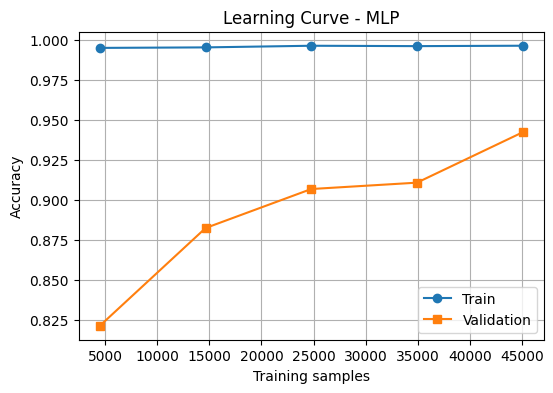


==================== SVM ====================


In [ ]:
results = []

for name, model in models:
    res = evaluate_model_with_learning_curve(
        name,
        model,
        X_train, y_train,
        X_val, y_val
    )
    results.append(res)


In [16]:
models = []
knn_base = KNeighborsClassifier(
    weights="distance",
    p=2,
    n_neighbors=3,
    leaf_size=50,
    n_jobs=-1
)
models.append(("KNN", knn_base))


==================== KNN ====================
Accuracy : 0.957160
Precision(macro): 0.957607
Recall(macro)   : 0.957159
F1-score(macro) : 0.957112
Fit time        : 0.16 sec


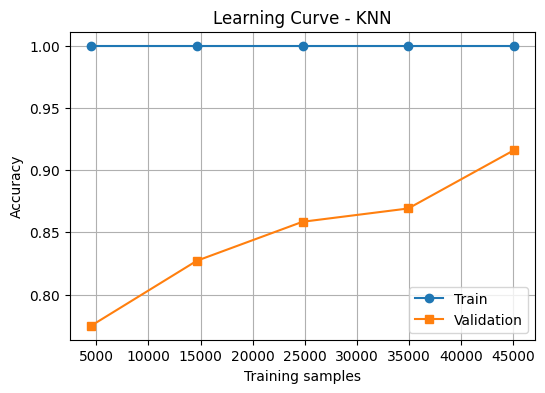

In [17]:

results = []

for name, model in models:
    res = evaluate_model_with_learning_curve(
        name,
        model,
        X_train, y_train,
        X_val, y_val
    )
    results.append(res)

